# QA Generation with GPT-4o Vision

Generate open-ended QA pairs for ultrasound video clips.
Each clip gets 3-5 QA pairs across different types:
- scene_description, sonographer_intent, action_guidance, knowledge, fine_grained

In [1]:
import sys, os
os.chdir("..")
sys.path.append("scripts")

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "REPLACED_BY_ENV_LOADER_SEE_README"  # <-- PUT YOUR KEY HERE

from qa_generation import *
from pathlib import Path
import json

## 1. Setup: Load a clip

In [3]:
# Video and clips paths
VIDEO = "UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4"
CLIPS_FILE = "results/clips/8V649L5Q368_clips.json"

# Load clips (from segmentation)
if Path(CLIPS_FILE).exists():
    with open(CLIPS_FILE) as f:
        clips_data = json.load(f)
    clips = clips_data["clips"]
    print(f"Loaded {len(clips)} clips")
    for c in clips:
        idx = c['clip_idx']
        start = c['start']
        end = c['end']
        dur = c['duration']
        print(f"  Clip {idx}: {start:.0f}-{end:.0f}s ({dur:.0f}s)")

else:
    print("No clips file found. Run segmentation first.")
    print("  python scripts/video_segmentation.py")

Loaded 10 clips
  Clip 0: 28-87s (59s)
  Clip 1: 87-250s (163s)
  Clip 2: 250-323s (73s)
  Clip 3: 323-399s (75s)
  Clip 4: 399-444s (45s)
  Clip 5: 444-551s (107s)
  Clip 6: 551-622s (71s)
  Clip 7: 622-771s (149s)
  Clip 8: 771-983s (212s)
  Clip 9: 983-1126s (144s)


## 2. Test on Single Clip

Try generating QA for just one clip to verify quality.

In [4]:
# Pick a clip to test (e.g., clip 0)
test_clip = clips[0]
print(f"Testing Clip {test_clip['clip_idx']}: {test_clip['start']:.1f}-{test_clip['end']:.1f}s")
print(f"Duration: {test_clip['duration']:.1f}s")
print(f"Text preview: {test_clip['text'][:200]}...")

Testing Clip 0: 28.0-87.5s
Duration: 59.5s
Text preview: To get started, we'll start with pneumothorax. Now, as a hospitalist, I don't diagnose a lot of pneumothoracies, right? My colleagues down on the ED are usually checking this out more than I am, but i...


Extracted 6 frames


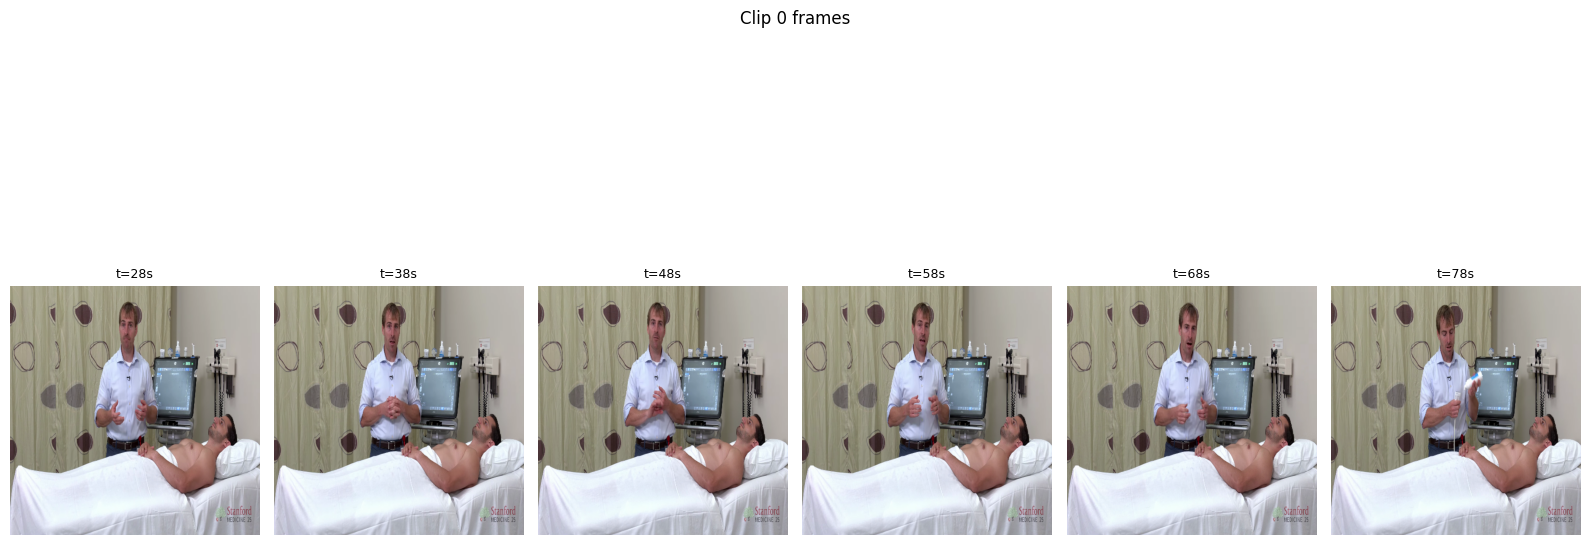

In [5]:
# Extract frames from this clip
frames = extract_clip_frames(VIDEO, test_clip["start"], test_clip["end"], num_frames=6)
print(f"Extracted {len(frames)} frames")

# Display frames
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(frames), figsize=(16, 8))
for i, (ax, frame) in enumerate(zip(axes, frames)):
    ax.imshow(frame[:,:,::-1])  # BGR to RGB
    t = test_clip["start"] + i * (test_clip["duration"] / len(frames))
    ax.set_title(f"t={t:.0f}s", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Clip {test_clip['clip_idx']} frames", fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# Generate QA for this clip
qa_pairs = generate_qa_for_clip(
    frames,
    test_clip["text"],
    video_type="hands_on_tutorial"
)

print(f"\nGenerated {len(qa_pairs)} QA pairs:\n")
for i, qa in enumerate(qa_pairs):
    print(f"--- QA {i+1} [{qa['type']}] ---")
    print(f"Q: {qa['question']}")
    print(f"A: {qa['answer']}")
    print()

  GPT-4o response: 7.6s | 1705 tokens

Generated 5 QA pairs:

--- QA 1 [scene_description] ---
Q: What is the instructor demonstrating in this video clip?
A: The instructor is preparing to demonstrate an ultrasound technique for detecting pneumothorax. He discusses the utility of ultrasound in this context and begins by explaining the use of a linear probe, which is suitable for this type of scan.

--- QA 2 [sonographer_intent] ---
Q: What is the diagnostic goal of the ultrasound scan being discussed?
A: The diagnostic goal is to rule out pneumothorax using ultrasound, which is noted for its high negative predictive value and sensitivity compared to chest X-rays.

--- QA 3 [next_action_guidance] ---
Q: What should the sonographer do next after positioning the patient?
A: After positioning the patient, the sonographer should apply gel to the probe and begin scanning the anterior chest wall to identify the pleural line and check for lung sliding, which would indicate the absence of pneum

Clip (Video + ASR Text) -> Q & A
训练：
Video + Question + (previous ASR)-> Answer

- 检查LiveCC QA的设计（什么时候发问）


In [7]:
result = generate_qa_for_video(VIDEO, clips_path=CLIPS_FILE, output_dir="results/qa")


QA Generation: 8V649L5Q368
  Video: UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4
  Clips: 10
  Model: gpt-4o

  Clip 0: 28.0-87.5s (59s)
    Extracted 6 frames
  GPT-4o response: 7.2s | 1702 tokens
    Generated 5 QA pairs

  Clip 1: 87.5-250.2s (163s)
    Extracted 6 frames
  GPT-4o response: 6.5s | 2140 tokens
    Generated 5 QA pairs

  Clip 2: 250.2-323.4s (73s)
    Extracted 6 frames
  GPT-4o response: 7.6s | 1788 tokens
    Generated 5 QA pairs

  Clip 3: 323.4-398.8s (75s)
    Extracted 6 frames
  GPT-4o response: 6.1s | 1793 tokens
    Generated 5 QA pairs

  Clip 4: 398.8-443.9s (45s)
    Extracted 6 frames
  GPT-4o response: 7.5s | 1709 tokens
    Generated 5 QA pairs

  Clip 5: 444.2-551.3s (107s)
    Extracted 6 frames
  GPT-4o response: 6.3s | 1962 tokens
    Generated 5 QA pairs

  Clip 6: 551.3-622.1s (71s)
    Extracted 6 frames
  GPT-4o response: 5.9s | 1817 tokens
    Generated 5 QA pairs

  Clip 7: 622.1-7